# Numerical Simulation Laboratory - Exercise 06

## INTRODUCTION

This exercise studies the one-dimensional Ising model in the canonical ensemble. The system is composed of $N$ spins

$$
s_i = \pm 1,
$$

with nearest-neighbour interaction, ferromagnetic coupling $J=1$, and periodic boundary conditions. In the units used here, $k_B=1$ and $\mu_B=1$, so $\beta=1/T$. The Hamiltonian is

$$
H = -J\sum_{i=1}^{N}s_i s_{i+1}-\frac{h}{2}\sum_{i=1}^{N}(s_i+s_{i+1}),
\qquad s_{N+1}=s_1.
$$

Here $h$ denotes the external magnetic field.

The target probability distribution is the Boltzmann distribution

$$
p(\{s_i\}) = \frac{e^{-\beta H(\{s_i\})}}{Z}.
$$

Since the 1D Ising model can be solved exactly, it is a useful test case for Monte Carlo sampling: the numerical estimates of the internal energy, specific heat, magnetic susceptibility and magnetization can be directly compared with the analytical curves.

### Metropolis sampling

In the Metropolis algorithm the Markov chain is built by proposing a trial move and then accepting or rejecting it with a probability chosen to sample the Boltzmann distribution. For the Ising model the natural move is the flip of one spin,

$$
s_i \longrightarrow -s_i.
$$

The proposal is symmetric, because the probability of proposing the flip from the old configuration to the new one is the same as the probability of proposing the reverse flip. Therefore, the proposal probability cancels in the Metropolis acceptance rule and only the ratio between the Boltzmann weights remains.

For a proposed flip of the spin $s_i$, the energy difference between the new and old configurations is

$$
\Delta E = 2s_i\left[J(s_{i-1}+s_{i+1})+h\right].
$$

The ratio between the probabilities of the new and old configurations is therefore

$$
\frac{p_{\text{new}}}{p_{\text{old}}}
=
\frac{e^{-\beta H_{\text{new}}}}{e^{-\beta H_{\text{old}}}}
=
e^{-\beta(H_{\text{new}}-H_{\text{old}})}
=
e^{-\beta \Delta E}.
$$

The Metropolis acceptance probability is then

$$
A = \min\left(1,e^{-\beta \Delta E}\right).
$$

If $\Delta E<0$, the move lowers the energy and is always accepted. If $\Delta E>0$, the move is accepted with probability $e^{-\beta\Delta E}$, allowing the system to explore configurations with higher energy according to the Boltzmann distribution.

### Gibbs sampling

Gibbs sampling, also called the heat-bath algorithm, updates a variable by drawing its new value directly from the conditional probability distribution determined by all the other variables. The name "heat-bath" comes from the idea that the selected spin is put in thermal contact with the rest of the system, which acts as a reservoir at temperature \(T\), and is then redrawn according to the corresponding equilibrium probability. In the 1D Ising model, when the spin $s_i$ is updated, all spins except $s_i$ are kept fixed. Because the Hamiltonian contains only nearest-neighbour interactions, the conditional probability depends only on the two neighbouring spins.

The local field acting on the spin $s_i$ is

$$
h_i^{\mathrm{loc}} = J(s_{i-1}+s_{i+1})+h.
$$

Here $J(s_{i-1}+s_{i+1})$ is the contribution due to the interaction with the two nearest-neighbour spins, while $h$ is the contribution of the external magnetic field.

The probability of assigning the value $s_i=+1$ is

$$
p(s_i=+1\mid s_{i-1},s_{i+1})
=\frac{e^{\beta h_i^{\mathrm{loc}}}}{e^{\beta h_i^{\mathrm{loc}}}+e^{-\beta h_i^{\mathrm{loc}}}}
=\frac{1}{1+e^{-2\beta h_i^{\mathrm{loc}}}}.
$$

The probability of assigning $s_i=-1$ is simply

$$
p(s_i=-1\mid s_{i-1},s_{i+1})=1-p(s_i=+1\mid s_{i-1},s_{i+1}).
$$

Unlike Metropolis, Gibbs sampling does not propose a flip and then test it: it directly resamples the spin from the correct conditional distribution. The update is therefore always accepted. The chain still needs equilibration and blocking analysis, but the absence of rejected moves makes Gibbs a different sampling strategy to compare with Metropolis.

### The role of temperature

The temperature enters both algorithms through $\beta=1/T$. In Metropolis, the proposed move is always a spin flip, but the probability of accepting a move that increases the energy depends on temperature through

$$
e^{-\beta\Delta E}.
$$

At low temperature, $\beta$ is larger, so energetically unfavourable flips are accepted less often. In Gibbs sampling, there is no rejection step, but the conditional probability also depends on temperature. At low temperature, it becomes more strongly biased toward the spin orientation favoured by the local field, while at high temperature it becomes closer to a random choice.

## EXERCISE 06.1

### Assignment prompt

Complete the NSL_simulator code to simulate a 1D Ising model with the Gibbs sampling algorithm (the Metropolis algorithm is already implemented) to sample the Boltzmann's weight $p(\{ s_i \}) = \exp(-\beta H)/Z$. Verify the possibility to restart from a previous spin configuration.

The code already computes the internal energy: $U(N,T) = \langle H \rangle$. Add the calculation of $C(N,T)$, $\chi(N,T)$, $M(N,T,h)$ and compute:
1. $U(N,T) = \langle H \rangle_{h=0}$
2. $C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$ 
3. $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$
4. $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$

as a function of $T$ in the range $\left[0.5;2.0\right]$ for a system of $N=50$ spins with $J=1$.

As usual, use data blocking and give an estimate of the statistical uncertainties.

- Show pictures of your estimations of $U(N,T)$, $C(N,T)$, $\chi(N,T)$, $M(N,T,h=0.02)$ and their uncertainties obtained with a large number of *MC steps* (e.g. $M\ge 10^5$) compared with the exact curves. In the same picture show your results obtained with both sampling methods, Metropolis and Gibbs.

A Monte Carlo step will consist in trying to flip one time all the spins of the system. Do not forget to equilibrate your simulations and to use blocking average with blocks large enough.

### Method

The simulations were performed for $N=50$ spins, $J=1$, and temperatures from $T=0.5$ to $T=2.0$ in steps of $0.1$. For each temperature, two production runs were carried out: one with the Metropolis update and one with the Gibbs update. The numerical results were then compared with the exact 1D Ising curves.

The input files were used as part of the production workflow. The file `input.dat` selected the simulation type, the temperature, the external field and the blocking parameters. In particular, `SIMULATION_TYPE = 2` corresponds to the 1D Ising Metropolis simulation, while `SIMULATION_TYPE = 3` corresponds to the 1D Ising Gibbs simulation. The value of `TEMP` was changed for the different temperatures, and the magnetic field was set to $h=0$ for $U/N$, $C$ and $\chi$, while $h=0.02$ was used for the magnetization.

The file `properties.dat` was used as the selector of the observables to be measured in a given run. Before launching the program, it was modified according to the quantity or set of quantities that had to be computed. When an observable name was present in `properties.dat`, the C++ code created the corresponding output file, activated the related measurement flag, and assigned the correct position in the measurement vector. After each run, the resulting data files were stored in folders labelled by method and temperature:

```text
Different_temperatures_output_metropolis/T_...
Different_temperatures_output_gibbs/T_...
```

Each final file contains the progressive block average and its statistical uncertainty. In the analysis below, the last block is used as the final estimate for each temperature.

### C++ implementation

The spin update is implemented in `System::move()`. The variable `_sim_type` selects the type of Monte Carlo update. In this exercise, `_sim_type == 2` corresponds to the Ising Metropolis simulation, while `_sim_type == 3` activates the Gibbs sampler for the Ising model.

```cpp
void System :: move(int i){ // Propose a MC move for particle i
  if(_sim_type == 3){ // Gibbs sampler for Ising

    double local_field, p_spinup;

    local_field = ( _J * (_particle(this->pbc(i-1)).getspin()
                        + _particle(this->pbc(i+1)).getspin() ) + _H );

    p_spinup = 1./( 1. + exp(- _beta*2.0*local_field));

    if( _rnd.Rannyu() < p_spinup){
      _particle(i).setspin(+1);
    }
    else{
      _particle(i).setspin(-1);
    }

  } else { // Metropolis
    if(_sim_type == 1){ // LJ system
      vec shift(_ndim);
      for(int j=0; j<_ndim; j++){
        shift(j) = _rnd.Rannyu(-1.0,1.0) * _delta;
      }
      _particle(i).translate(shift, _side);
      if(this->metro(i)){
        _particle(i).acceptmove();
        _naccepted++;
      } else _particle(i).moveback();
    } else { // Ising 1D
      if(this->metro(i)){
        _particle(i).flip();
        _naccepted++;
      }
    }
  }
  return;
}
```

#### Definition of measured observables in the C++ code

The observables are activated by reading `properties.dat` inside `System::initialize_properties()`. This is the part of the code where the variables to be measured are effectively created: the output file is initialized, a Boolean flag is switched on, and an index in the vector `_measurement` is assigned.

```cpp
else if( property == "TOTAL_ENERGY" ){
  ofstream coutt("../OUTPUT_Ex_06_1/total_energy.dat");
  coutt << "#     BLOCK:   ACTUAL_TE:    TE_AVE:      ERROR:" << endl;
  coutt.close();
  _nprop++;
  _measure_tenergy = true;
  _index_tenergy = index_property;
  index_property++;
}
else if( property == "MAGNETIZATION" ){
  ofstream coutpr("../OUTPUT_Ex_06_1/magnetization.dat");
  coutpr << "#     BLOCK:   ACTUAL_M:     M_AVE:       ERROR:" << endl;
  coutpr.close();
  _nprop++;
  _measure_magnet = true;
  _index_magnet = index_property;
  index_property++;
}
else if( property == "SPECIFIC_HEAT" ){
  ofstream coutpr("../OUTPUT_Ex_06_1/specific_heat.dat");
  coutpr << "#     BLOCK:   ACTUAL_CV:    CV_AVE:      ERROR:" << endl;
  coutpr.close();
  _nprop += 2;
  _measure_cv = true;
  _index_cv = index_property;
  index_property++;
  _index_cv2 = index_property;
  index_property++;
}
else if( property == "SUSCEPTIBILITY" ){
  ofstream coutpr("../OUTPUT_Ex_06_1/susceptibility.dat");
  coutpr << "#     BLOCK:   ACTUAL_X:     X_AVE:       ERROR:" << endl;
  coutpr.close();
  _nprop++;
  _measure_chi = true;
  _index_chi = index_property;
  index_property++;
}
```

The specific heat needs two entries in `_measurement`, because the estimator requires both $H$ and $H^2$. The other three observables require one entry each.

#### Measurement formulas in the C++ code

During the simulation, `System::measure()` fills the components of `_measurement`. Each measured quantity is associated with a specific index, defined when the corresponding property is read from `properties.dat`.

For the Ising model, the **total energy** per spin is

$$
\frac{H}{N}
=
-\frac{J}{N}\sum_{i=1}^{N}s_i s_{i+1}
-\frac{h}{2N}\sum_{i=1}^{N}(s_i+s_{i+1}).
$$

In the code, this quantity is accumulated by looping over nearest-neighbour pairs:

```cpp
tenergy_temp += - _J * s_i * s_j - 0.5 * _H * (s_i + s_j);
tenergy_temp /= double(_npart);
_measurement(_index_tenergy) = tenergy_temp;
```

The **magnetization** per spin, measured in the simulations with external field \(h=0.02\), is

$$
\frac{M}{N}
=
\frac{1}{N}\sum_{i=1}^{N}s_i.
$$

It is measured in the code as

```cpp
magnetization += s_i;
_measurement(_index_magnet) = magnetization / double(_npart);
```

The **specific heat** is obtained from the fluctuations of the total energy:

$$
C
=
\frac{\beta^2}{N}
\left(
\langle H^2\rangle - \langle H\rangle^2
\right).
$$

For this reason, the code stores both $H$ and $H^2$ during the measurement step:

```cpp
_measurement(_index_cv)  = energy;
_measurement(_index_cv2) = energy * energy;
```

Then, in `System::averages()`, the block estimator is computed as

```cpp
double cv_block = (_beta * _beta / double(_npart)) *
                  (ave_H2 - ave_H * ave_H);
```

Finally, the **magnetic susceptibility** at zero external field is computed from the fluctuations of the total magnetization:

$$
\chi
=
\frac{\beta}{N}
\left(
\langle M^2\rangle - \langle M\rangle^2
\right).
$$

Since the susceptibility is measured at $h=0$, the symmetry of the model gives $\langle M\rangle = 0$ in the exact canonical average, so the estimator used in the code is

$$
\chi
\simeq
\frac{\beta}{N}\langle M^2\rangle.
$$

The corresponding code is

```cpp
chi_temp += s_i;
chi_temp_2 = chi_temp * chi_temp;
_measurement(_index_chi) = (chi_temp_2 / double(_npart)) * _beta;
```

### Equilibration and restart

Before collecting measurements, the Markov chain must be sufficiently close to equilibrium. In `Ex_06_1.cpp`, the preliminary equilibration depends on the value of `RESTART`.

When `RESTART = 0`, the simulation starts from a newly initialized spin configuration. In this case, the code performs 10000 `SYS.step()` calls before accumulating block averages. This longer equilibration is needed because the initial configuration is not guaranteed to be representative of the Boltzmann distribution at the chosen temperature.

When `RESTART = 1`, the simulator reads the saved spin configuration from `OUTPUT_Ex_06_1/CONFIG/config.spin` and then performs 1000 additional `SYS.step()` calls before measurements. This shorter equilibration is used because the starting configuration already comes from a previous Monte Carlo simulation and is therefore expected to be closer to equilibrium than a completely new configuration. The extra steps allow the system to adapt if the temperature or the sampling algorithm has been changed.

Changing only `properties.dat` does not change the physical state being sampled: it only changes which observables are measured and written to file. Therefore, in that case the restart is mainly useful to avoid repeating a full equilibration from scratch while measuring different quantities for the same system.

For the Ising simulation, one call to `SYS.step()` consists of `_npart` attempted spin updates. With \(N=50\), the equilibration therefore corresponds to about \(10000 \times 50\) attempted spin updates when `RESTART = 0`, and about \(1000 \times 50\) attempted spin updates when `RESTART = 1`.

At the end of each simulation, the final spin configuration is written again to `OUTPUT_Ex_06_1/CONFIG/config.spin`, so that it can be used as the starting configuration for a later run. This verifies the possibility of restarting the Ising simulation from a previous spin configuration.

### Number of MC steps

The production averages were computed using 20 blocks of 20000 Monte Carlo steps each, corresponding to

$$
20 \times 20000 = 4 \times 10^5
$$

Monte Carlo steps for each temperature and for each sampling method. This number is larger than the suggested scale \(M \geq 10^5\) given in the assignment.

In the Ising simulation, one Monte Carlo step consists of trying to update all the spins of the system once. The simulations were equilibrated before collecting measurements, and the final estimates and uncertainties were obtained with the data blocking method. This procedure was applied to all the observables required by the assignment: internal energy \(U(N,T)\), specific heat \(C(N,T)\), magnetic susceptibility \(\chi(N,T)\), and magnetization \(M(N,T,h=0.02)\), comparing both Metropolis and Gibbs sampling with the exact analytical curves.

### Results

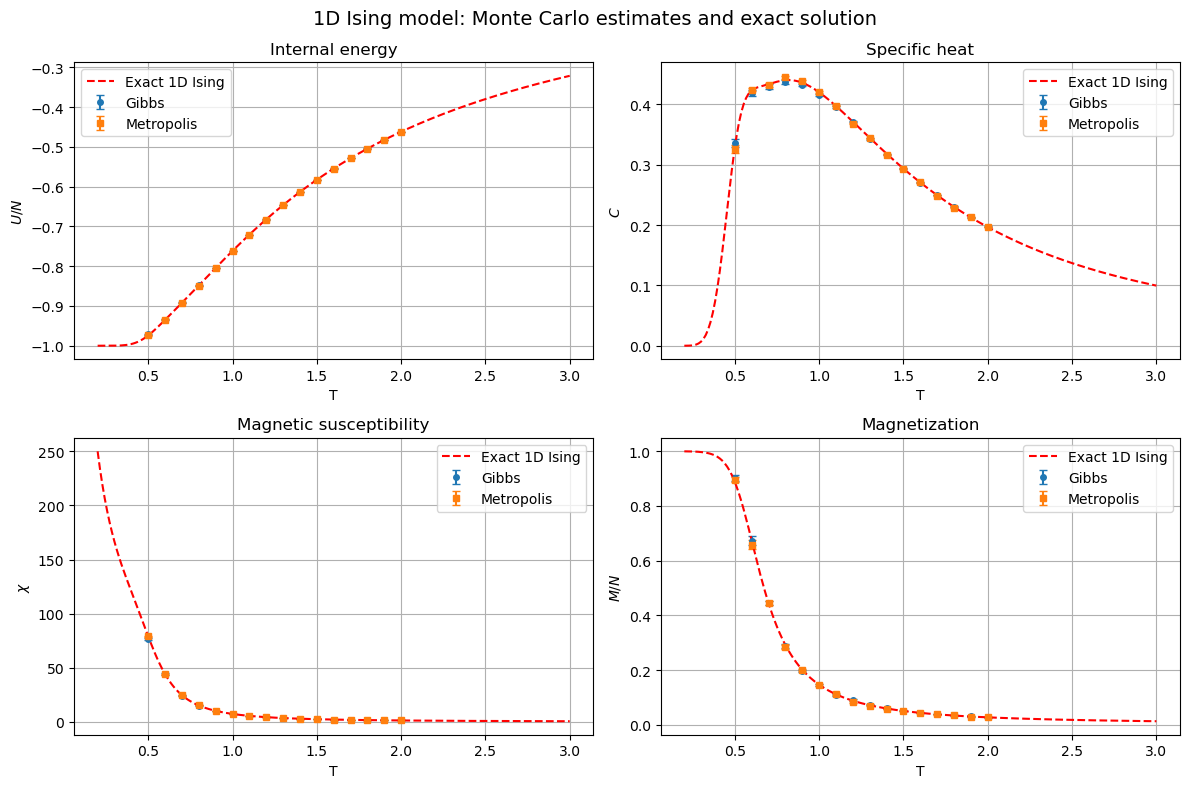

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Temperatures used in the production runs
temperature_list = np.round(np.arange(0.5, 2.0 + 0.1, 0.1), 1)

base_path_gibbs = "Different_temperatures_output_gibbs"
base_path_metropolis = "Different_temperatures_output_metropolis"

def read_data(base_path, temperature_list, filename, columns):
    """Read the final progressive average and uncertainty for each temperature."""
    T_plot, ave_list, error_list = [], [], []

    for T in temperature_list:
        folder = f"T_{T:.1f}"
        file_path = os.path.join(base_path, folder, filename)

        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        df = pd.read_csv(file_path, sep=r"\s+", comment="#", header=None, names=columns)
        df = df.apply(pd.to_numeric, errors="coerce").dropna()

        if df.empty:
            print(f"No numerical data found in {file_path}")
            continue

        final_row = df.iloc[-1]
        T_plot.append(T)
        ave_list.append(final_row[columns[2]])
        error_list.append(final_row["ERROR"])

    return np.array(T_plot), np.array(ave_list), np.array(error_list)

T_gibbs_te, te_gibbs, err_gibbs_te = read_data(
    base_path_gibbs, temperature_list, "total_energy.dat",
    ["BLOCK", "ACTUAL_TE", "TE_AVE", "ERROR"]
)
T_metro_te, te_metro, err_metro_te = read_data(
    base_path_metropolis, temperature_list, "total_energy.dat",
    ["BLOCK", "ACTUAL_TE", "TE_AVE", "ERROR"]
)

T_gibbs_cv, cv_gibbs, err_gibbs_cv = read_data(
    base_path_gibbs, temperature_list, "specific_heat.dat",
    ["BLOCK", "ACTUAL_CV", "CV_AVE", "ERROR"]
)
T_metro_cv, cv_metro, err_metro_cv = read_data(
    base_path_metropolis, temperature_list, "specific_heat.dat",
    ["BLOCK", "ACTUAL_CV", "CV_AVE", "ERROR"]
)

T_gibbs_chi, chi_gibbs, err_gibbs_chi = read_data(
    base_path_gibbs, temperature_list, "susceptibility.dat",
    ["BLOCK", "ACTUAL_X", "X_AVE", "ERROR"]
)
T_metro_chi, chi_metro, err_metro_chi = read_data(
    base_path_metropolis, temperature_list, "susceptibility.dat",
    ["BLOCK", "ACTUAL_X", "X_AVE", "ERROR"]
)

T_gibbs_m, m_gibbs, err_gibbs_m = read_data(
    base_path_gibbs, temperature_list, "magnetization.dat",
    ["BLOCK", "ACTUAL_M", "M_AVE", "ERROR"]
)
T_metro_m, m_metro, err_metro_m = read_data(
    base_path_metropolis, temperature_list, "magnetization.dat",
    ["BLOCK", "ACTUAL_M", "M_AVE", "ERROR"]
)

# Exact 1D Ising curves
points = 200
T_theory = np.linspace(0.2, 3.0, num=points)
J = 1.0
Ns = 50
h = 0.02
beta = 1.0 / T_theory

th = np.tanh(J / T_theory)
thN = th**Ns
ch = 1.0 / th

energy_theory = -J * (th + ch * thN) / (1.0 + thN)

specific_heat_theory = ((beta * J) ** 2) * (
    ((1.0 + thN + (Ns - 1.0) * th**2 + (Ns - 1.0) * ch**2 * thN) / (1.0 + thN))
    - Ns * ((th + ch * thN) / (1.0 + thN)) ** 2
)

susceptibility_theory = beta * np.exp(2.0 * beta * J) * (1.0 - thN) / (1.0 + thN)

rad = np.sqrt(np.exp(2.0 * beta * J) * np.cosh(beta * h)**2 - 2.0 * np.sinh(2.0 * beta * J))
lambda_1 = np.exp(beta * J) * np.cosh(beta * h) + rad
lambda_2 = np.exp(beta * J) * np.cosh(beta * h) - rad
Z = lambda_1**Ns + lambda_2**Ns

magnetization_theory = (
    np.exp(beta * J) * np.sinh(beta * h) *
    (
        lambda_1**(Ns - 1.0) * (1.0 + np.exp(beta * J) * np.cosh(beta * h) / rad)
        + lambda_2**(Ns - 1.0) * (1.0 - np.exp(beta * J) * np.cosh(beta * h) / rad)
    )
) / Z

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

plots = [
    (axs[0, 0], T_gibbs_te, te_gibbs, err_gibbs_te, T_metro_te, te_metro, err_metro_te,
     energy_theory, "Internal energy", "$U/N$"),
    (axs[0, 1], T_gibbs_cv, cv_gibbs, err_gibbs_cv, T_metro_cv, cv_metro, err_metro_cv,
     specific_heat_theory, "Specific heat", "$C$"),
    (axs[1, 0], T_gibbs_chi, chi_gibbs, err_gibbs_chi, T_metro_chi, chi_metro, err_metro_chi,
     susceptibility_theory, "Magnetic susceptibility", "$\\chi$"),
    (axs[1, 1], T_gibbs_m, m_gibbs, err_gibbs_m, T_metro_m, m_metro, err_metro_m,
     magnetization_theory, "Magnetization", "$M/N$"),
]

for ax, Tg, yg, eg, Tm, ym, em, y_theory, title, ylabel in plots:
    ax.errorbar(Tg, yg, yerr=eg, fmt="o", markersize=4, capsize=3, label="Gibbs")
    ax.errorbar(Tm, ym, yerr=em, fmt="s", markersize=4, capsize=3, label="Metropolis")
    ax.plot(T_theory, y_theory, "r--", label="Exact 1D Ising")
    ax.set_xlabel("T")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

plt.suptitle("1D Ising model: Monte Carlo estimates and exact solution", fontsize=14)
plt.tight_layout()
plt.show()

### Comment

The numerical estimates obtained with both Metropolis and Gibbs sampling are statistically compatible with the exact analytical curves. This indicates that both transition rules correctly sample the same equilibrium Boltzmann distribution after equilibration.

At lower temperatures, the internal energy is lower, consistently with the exact curve and with the fact that the ferromagnetic interaction favours aligned neighbouring spins. At higher temperatures, thermal fluctuations become more relevant and the energy increases.

The largest deviations from the exact curves are observed at the lowest temperatures. This is reasonable in view of the temperature dependence of the Monte Carlo updates discussed above. In this region, finite statistics, residual equilibration effects and correlations between successive configurations can have a more visible impact on the estimates.

The magnetization was measured with a small external field, \(h=0.02\), as required by the assignment. This avoids the symmetry between positive and negative magnetization that would be present at \(h=0\).

The important point is that, although Metropolis and Gibbs update the spins in different ways, both methods give results consistent with the exact analytical solution.